In [1]:
library(dplyr)
library(tidyr)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
plot <- function(m){
    nll <- read.table(paste0("./results/nll_",m,".txt"), skip = 2, header = FALSE)
    colnames(nll) <- c("theta_0","theta_1","nll")
    
    optima <- read.table(paste0("./results/nll_",m,".txt"), nrow = 2, header = FALSE)
    colnames(optima) <- c("theta_0","theta_1")

    p <- ggplot(nll, aes(x = theta_0, y = theta_1, fill = nll)) +
      geom_tile() +
      scale_fill_gradient(low = "white", high = "red") +
      geom_point(
        data = optima[1, ],
        aes(x = theta_0, y = theta_1),
        inherit.aes = FALSE,
        shape = 21, fill = NA, colour = "black", size = 4, stroke = 1.2
      ) +
      geom_point(
        data = optima[2, ],
        aes(x = theta_0, y = theta_1),
        inherit.aes = FALSE,
        shape = 21, fill = "black", colour = "black", size = 4
      ) +
      geom_point(
        data = nll[which.min(nll$nll), ],
        aes(x = theta_0, y = theta_1),
        inherit.aes = FALSE,
        shape = 16, colour = "green", size = 4
      ) +
      theme_minimal()
    
    print(p)
    }

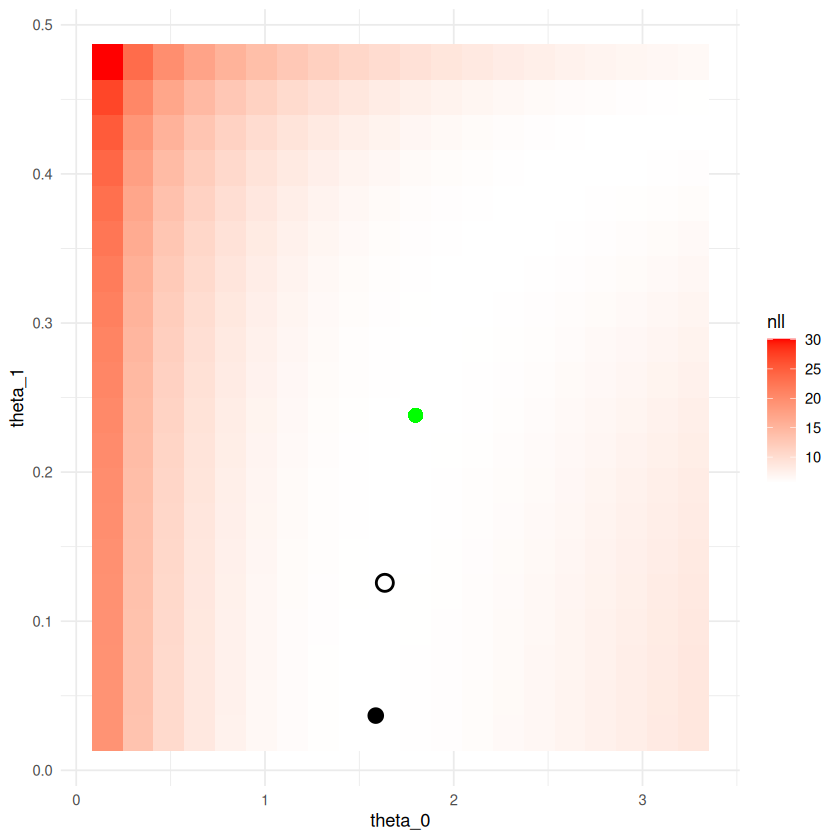

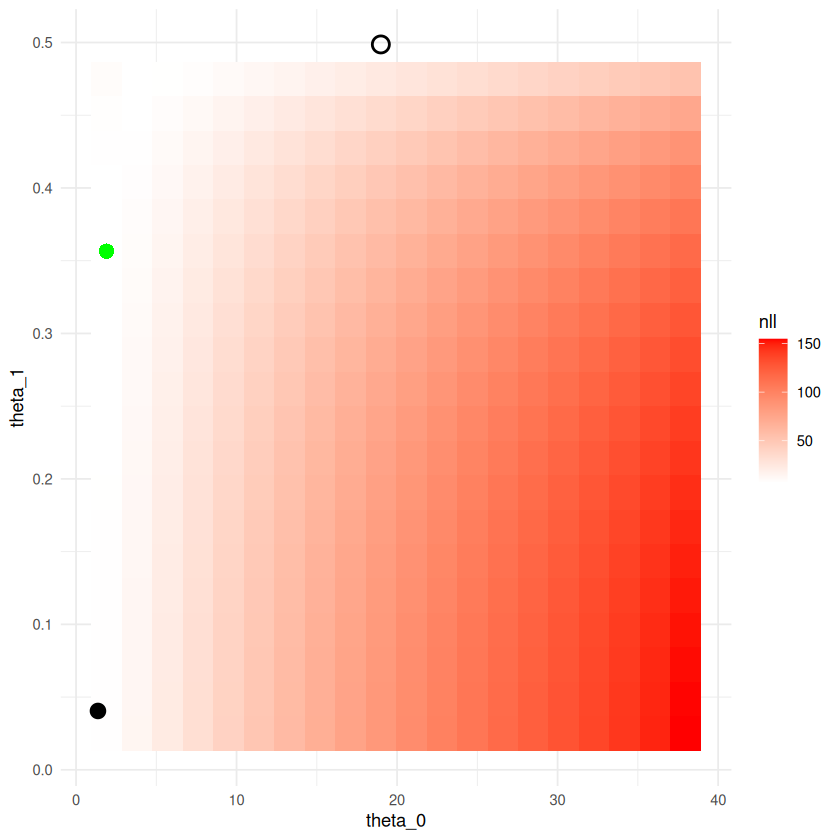

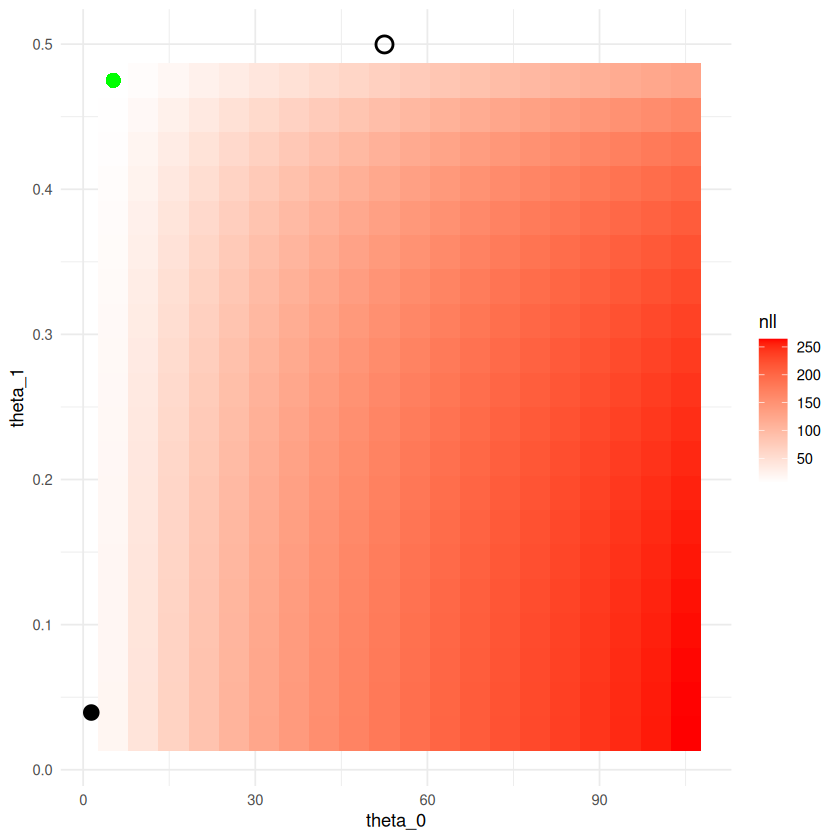

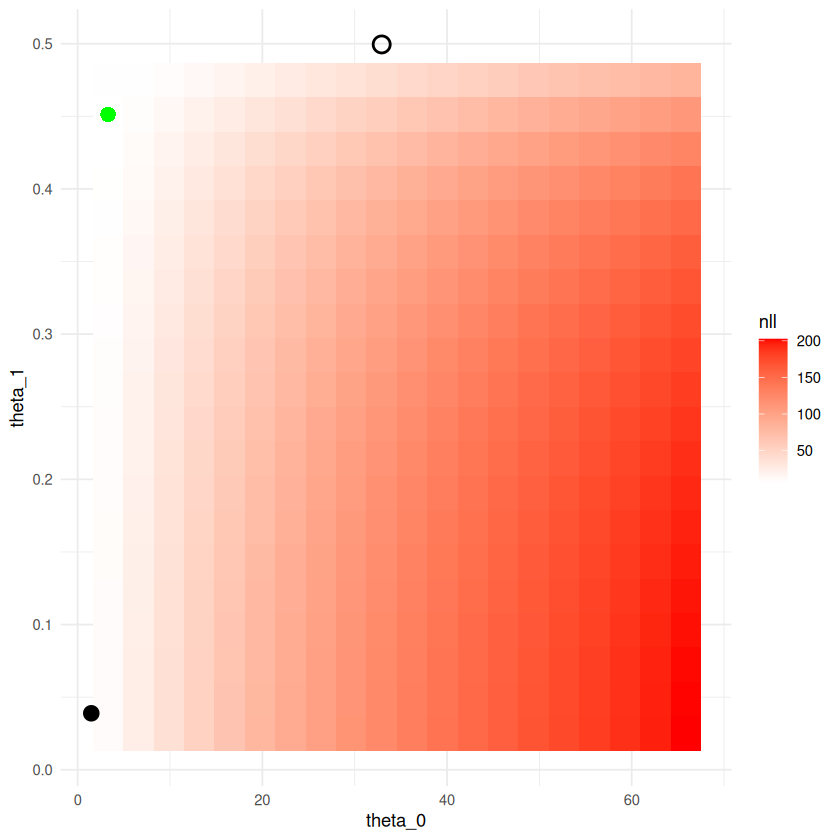

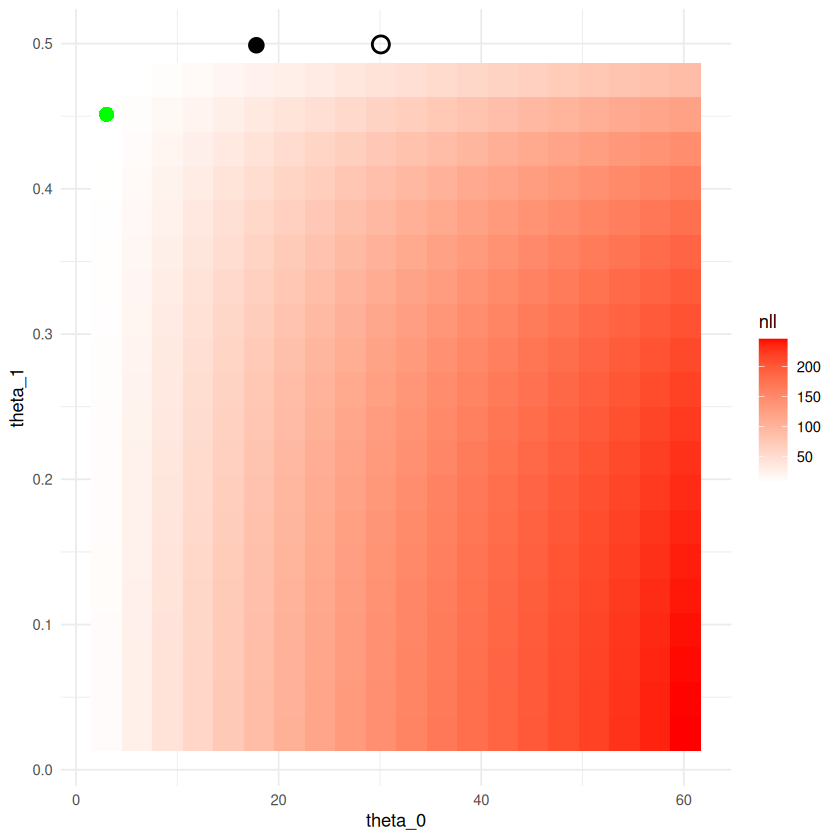

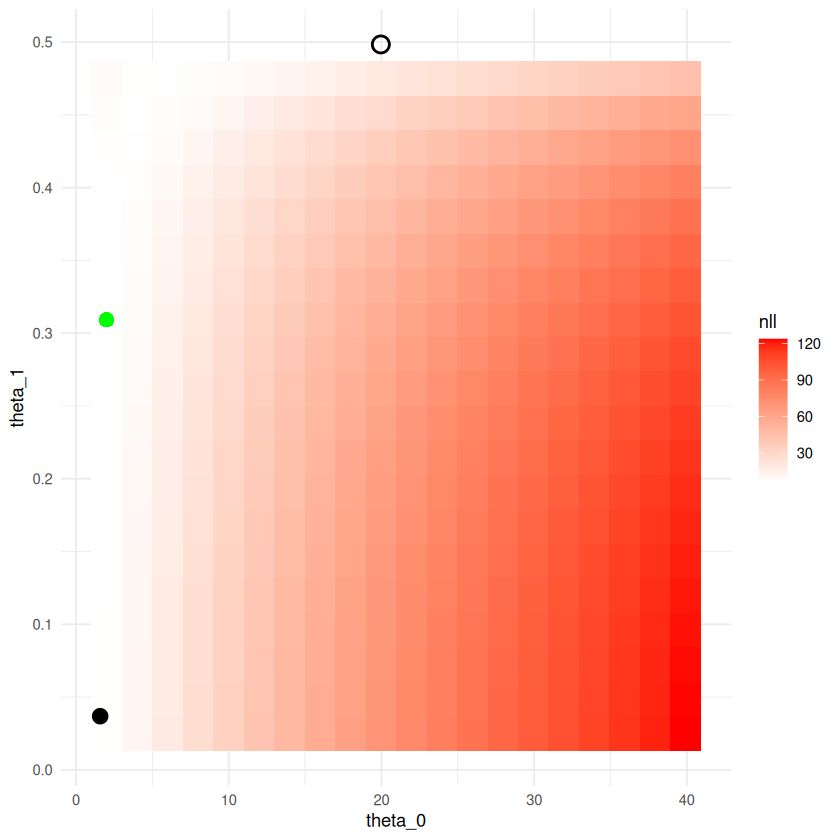

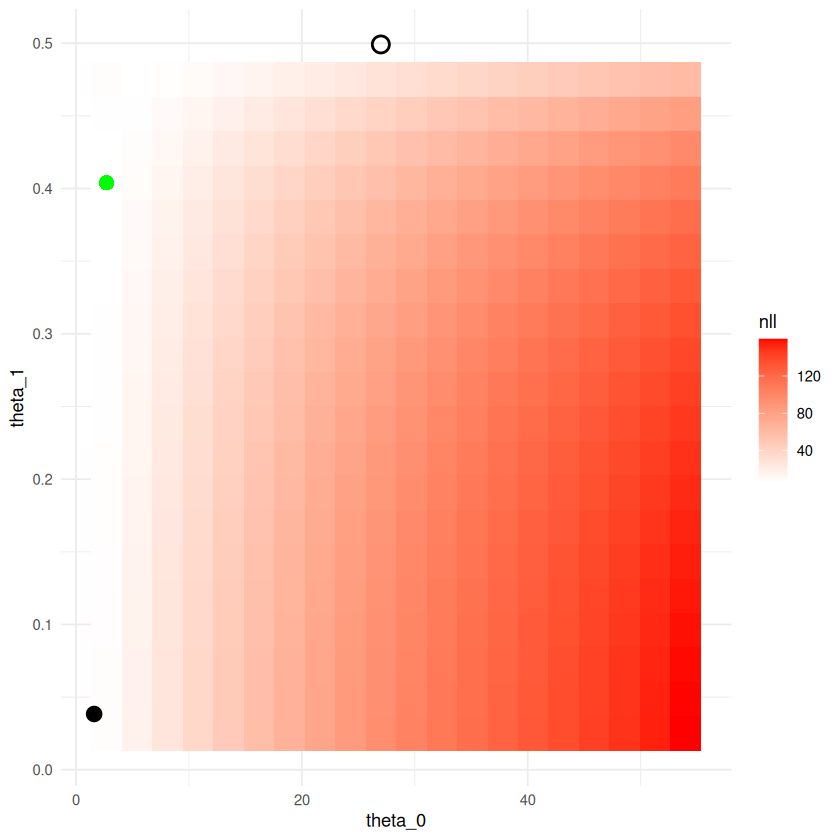

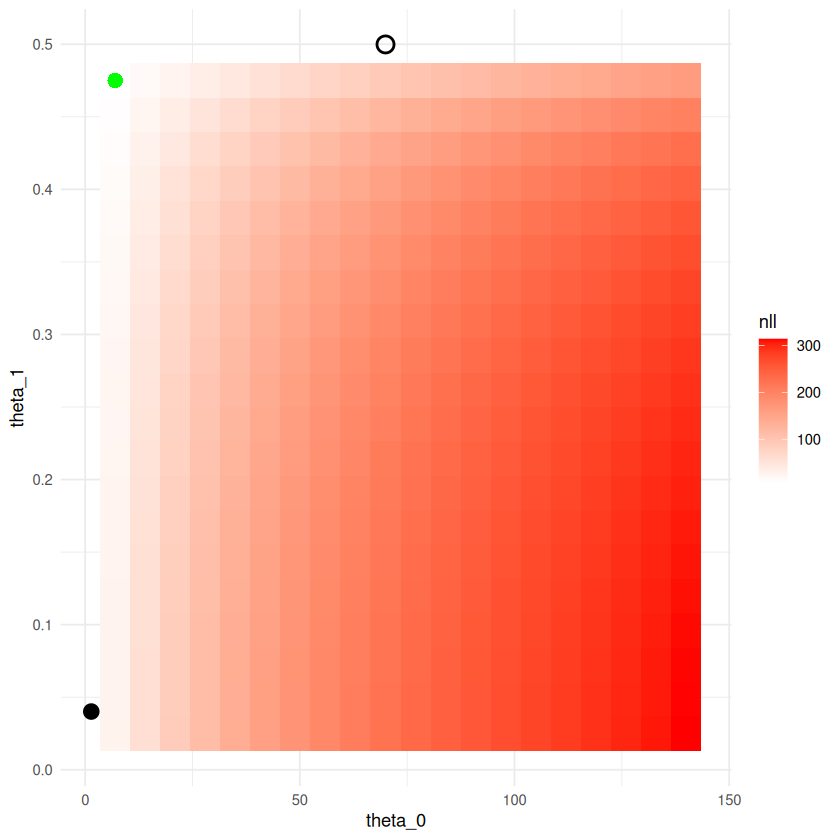

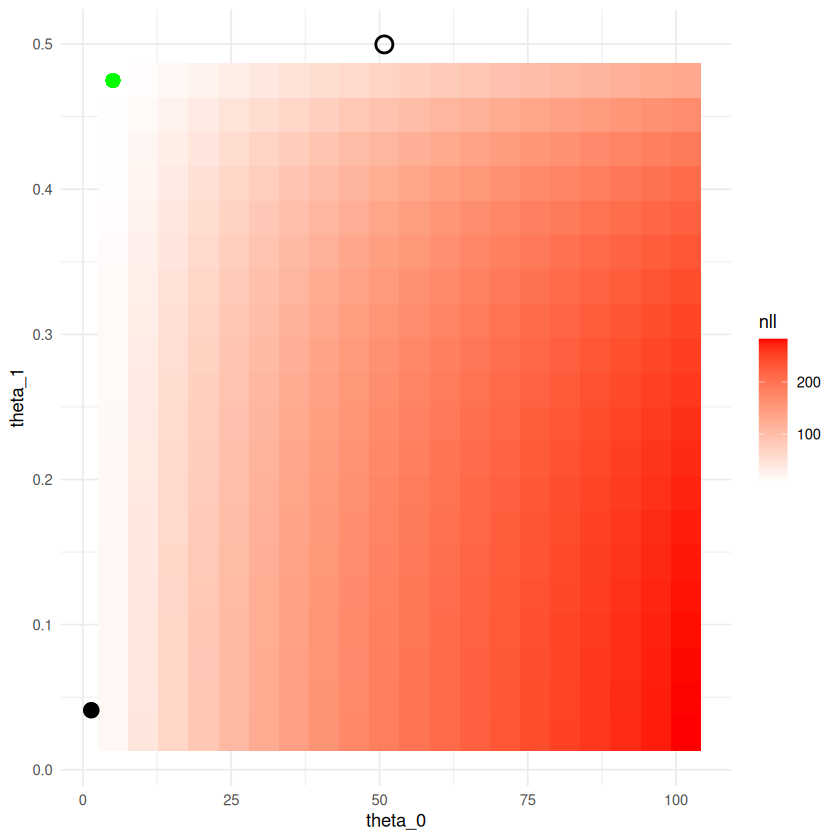

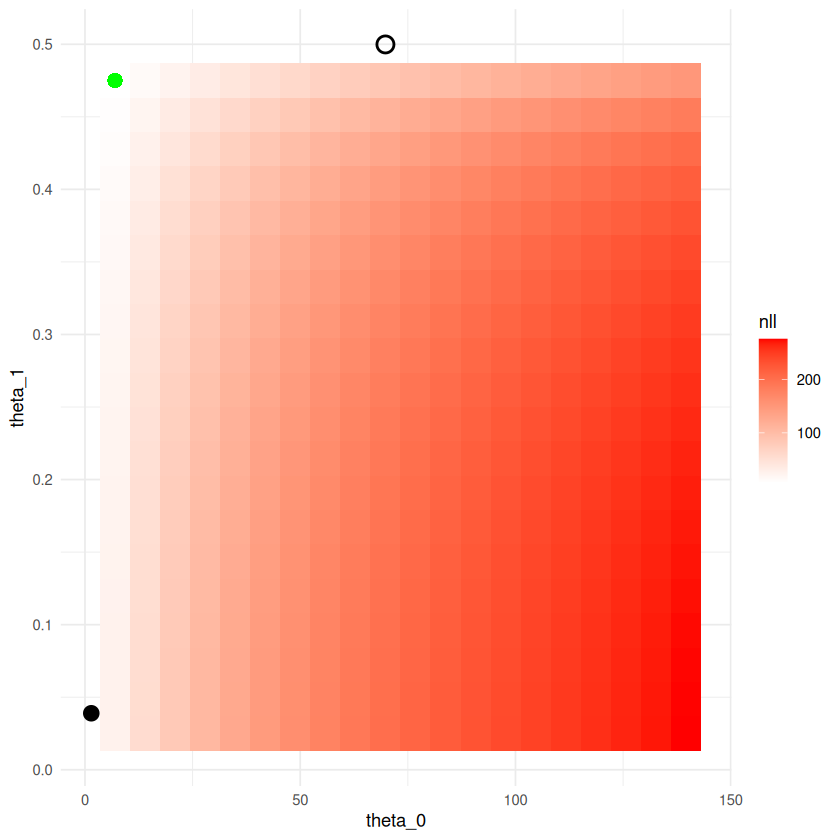

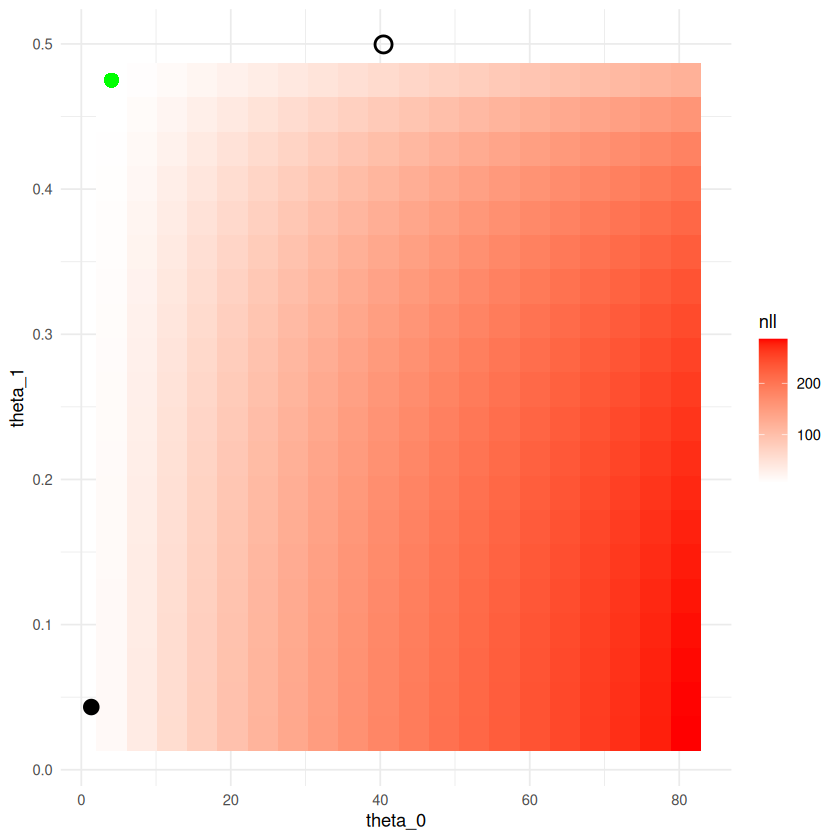

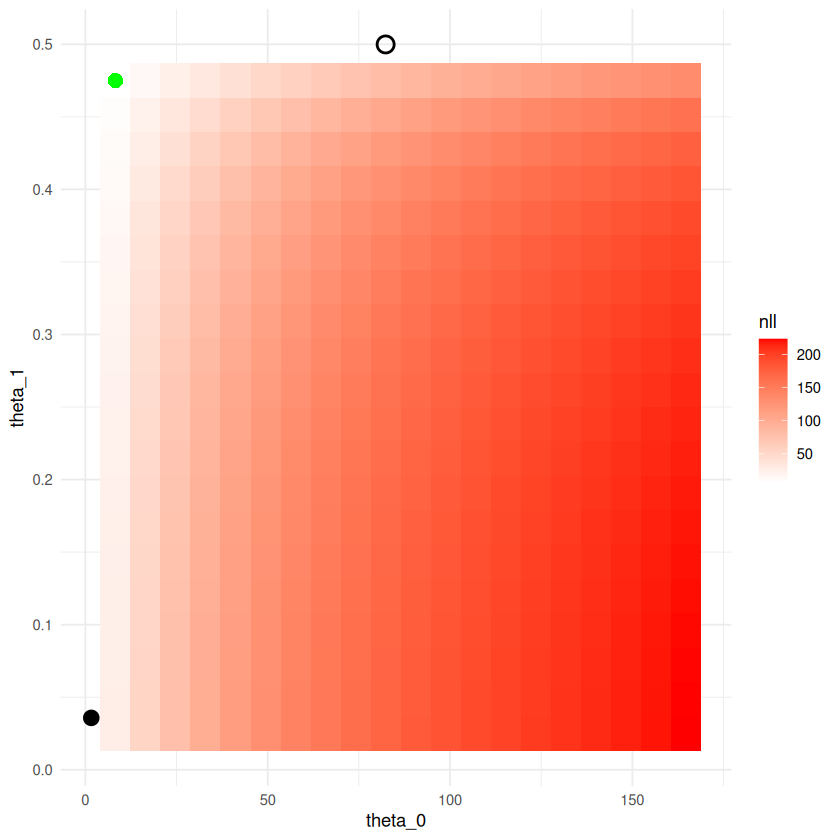

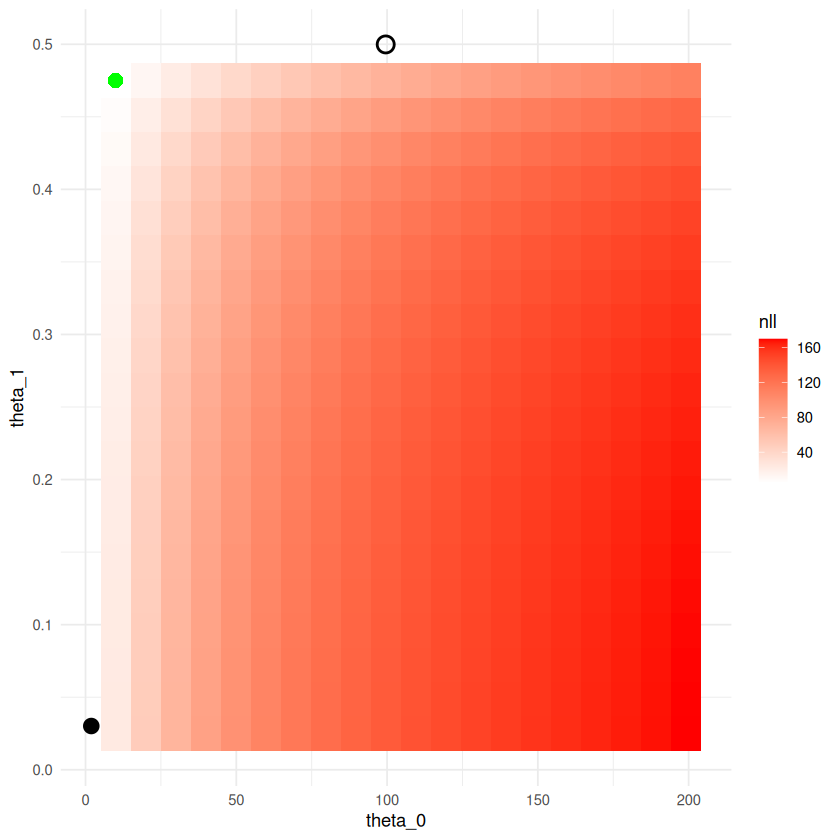

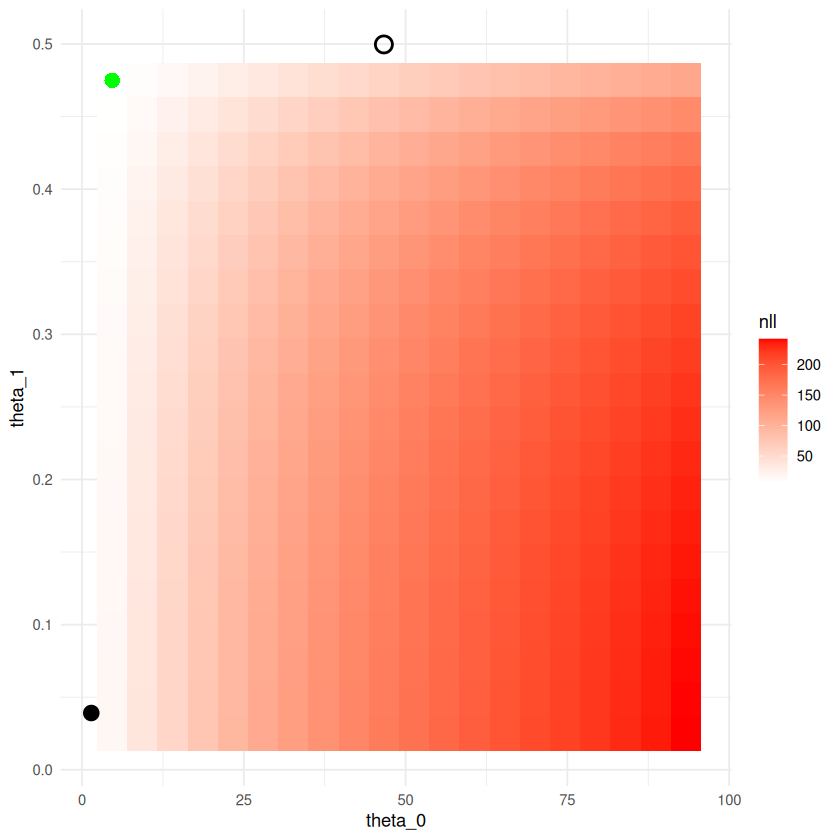

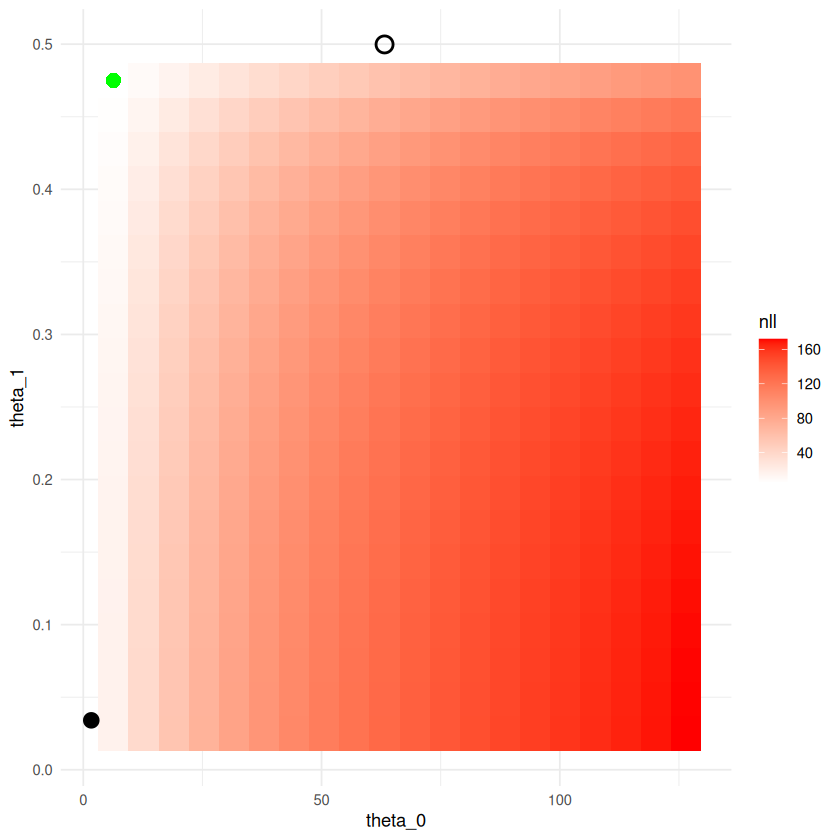

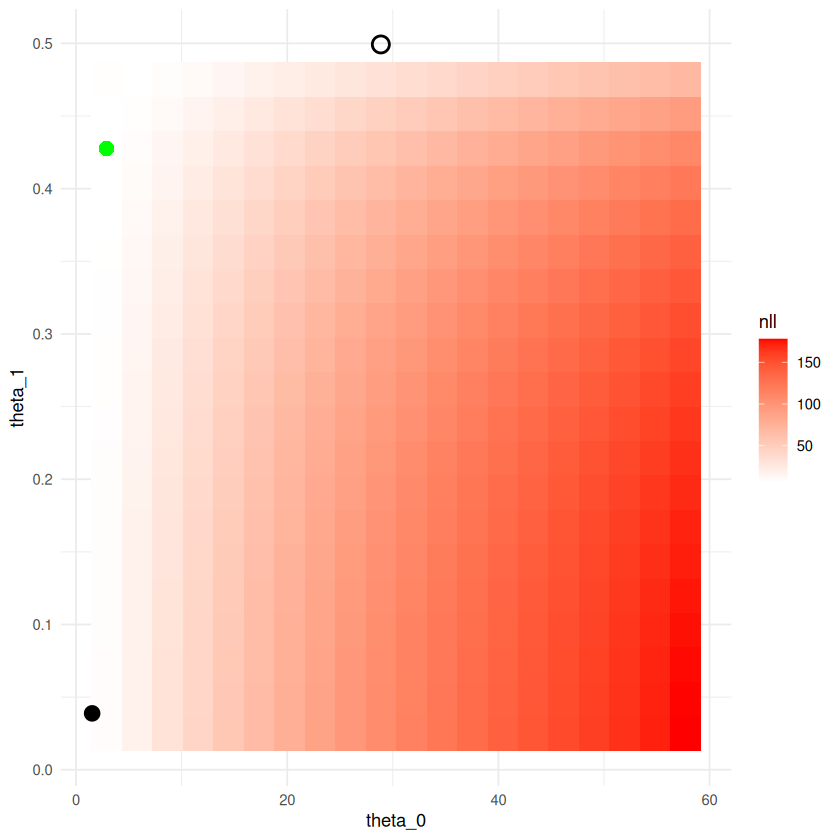

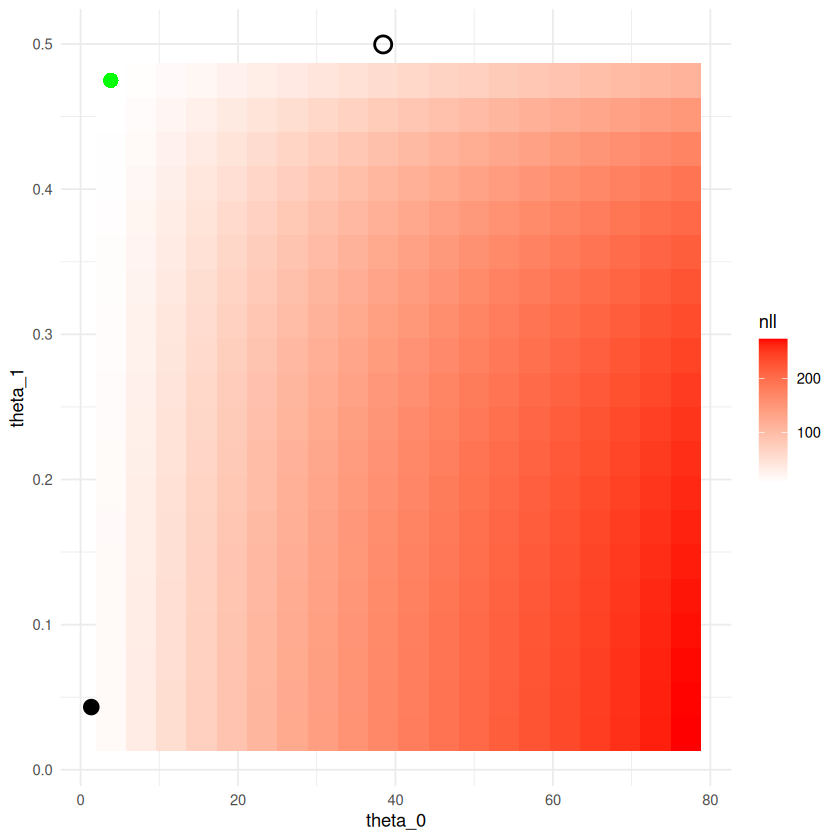

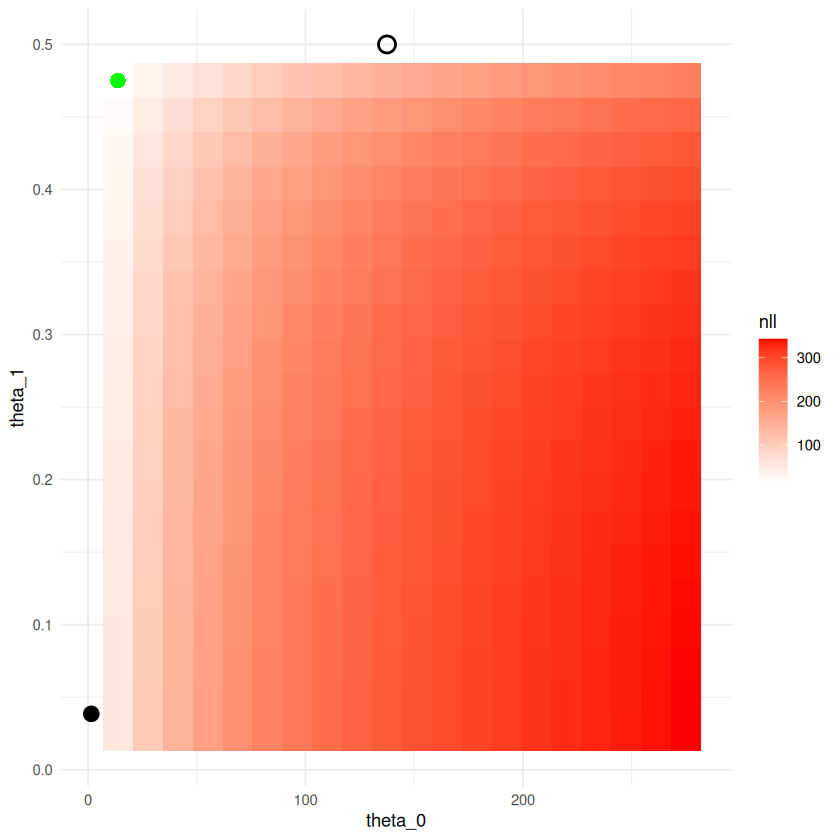

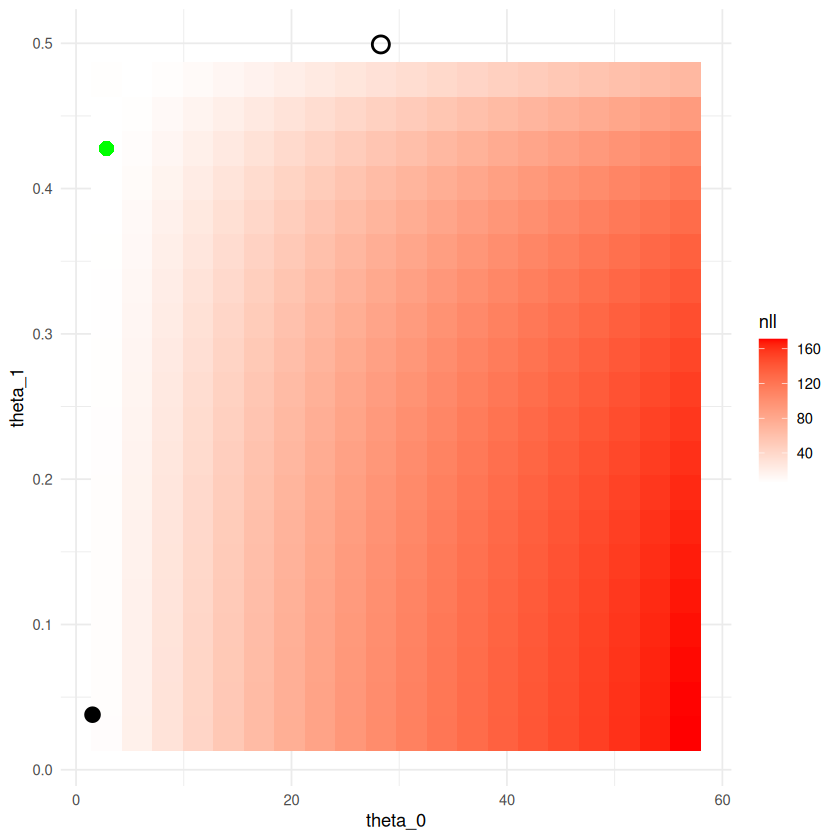

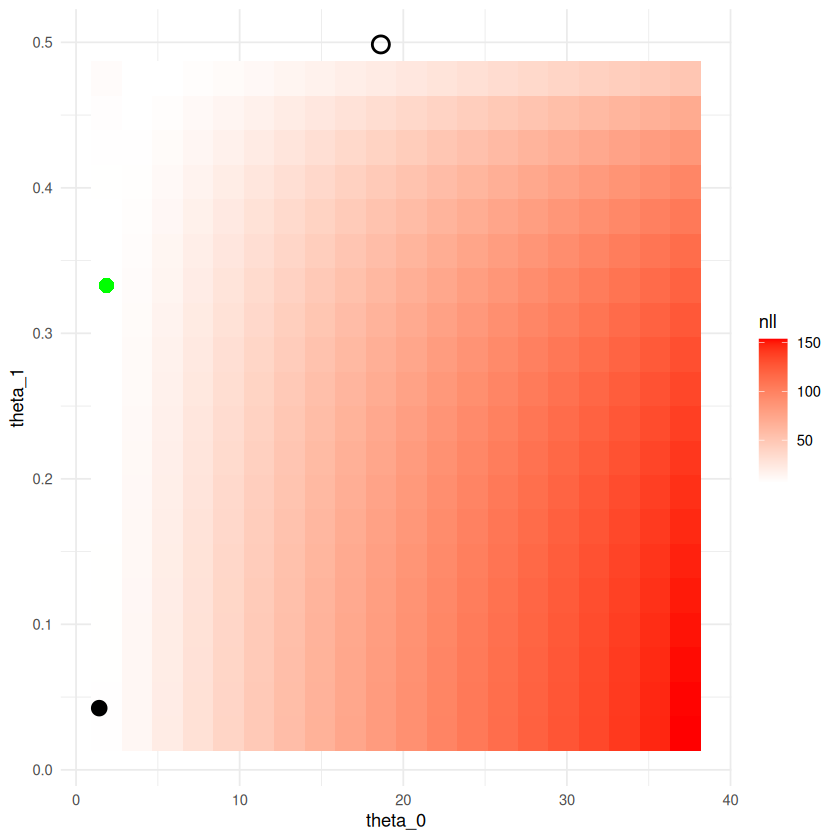

In [3]:
for (m in 0:19){
    plot(m)
}

In [4]:
plot_theta_k <- function(i, m){
    # i is the order number of the specific theta_k interested in
    # m is the macrorep

    # get data
    nll <- read.table(paste0("./results/nll_per_theta_k_",m,".txt"), header = FALSE)
    colnames(nll) <- c("theta_1","theta_0","nll","optimum")

    # filtered data for plot
    df_line <- nll %>% filter(theta_1 == unique(theta_1)[i], optimum=="False")
    df_point <- nll %>% filter(theta_1 == unique(theta_1)[i], optimum=="True")

    # plot
    p <- ggplot(df_line, aes(x = theta_0, y = nll)) +
    geom_line() + 
    geom_point(
        data = df_point,
        aes(x = theta_0, y = nll),
        inherit.aes = FALSE,
        shape = 16, colour = "green", size = 4
    )
    print(p)
    }

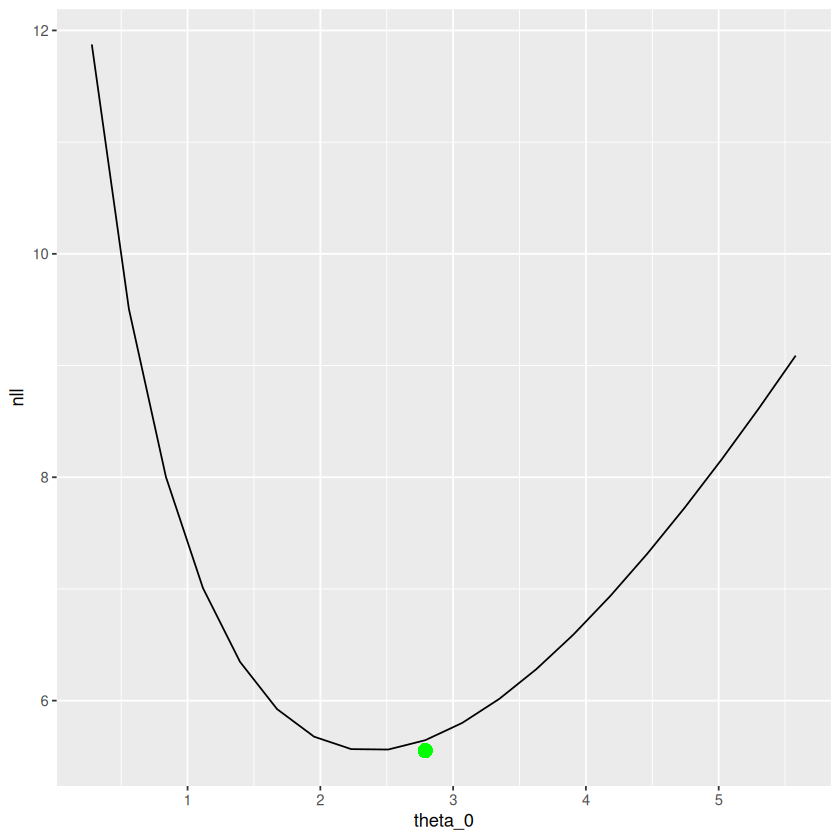

In [5]:
plot_theta_k(i=2, m=6)

In [2]:
plot_all_samples <- function(m){
    # get data
    nll <- read.table(paste0("./results/nll_per_theta_k_",m,".txt"), header = FALSE)
    colnames(nll) <- c("theta_1","theta_0","nll","optimum")

    # data for plot
    df_line <- nll %>% filter(optimum=="False")
    df_point_blue <- nll %>% filter(optimum=="True") %>% filter(nll==min(nll)) # best one picked with optimising separately
    df_point_green <- nll %>% filter(optimum=="False") %>% filter(nll==min(nll)) # true best of the many evaluations we take

    # plot
    p <- ggplot(df_line, aes(x = theta_0, y = theta_1, colour = nll)) +
    geom_point() +
    scale_colour_gradient(low = "white", high = "red") +
    geom_point(
        data = df_point_blue,
        aes(x = theta_0, y = theta_1),
        inherit.aes = FALSE,
        shape = 16, colour = "blue", size = 6
    ) +    
    geom_point(
        data = df_point_green,
        aes(x = theta_0, y = theta_1),
        inherit.aes = FALSE,
        shape = 17, colour = "green", size = 4
    )   
    print(p)

    }

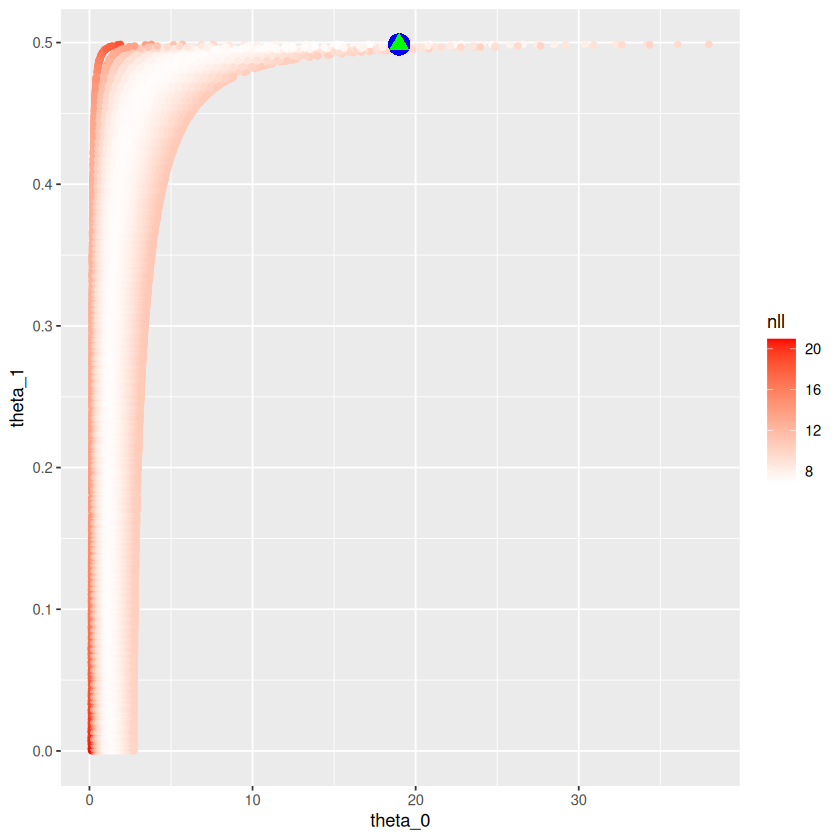

In [3]:
plot_all_samples(1)

In [4]:
plot_methods <- function(m, optim_meth){
    # get data
    nll <- read.table(paste0("./results/nll_optim_methods_",m,".txt"), header = FALSE)
    colnames(nll) <- c("theta_1","theta_0","nll","method")

    # data for plot
    df <- nll %>% filter(method=="none")
    df_point_blue <- nll %>% filter(method=="separate") %>% filter(nll==min(nll)) # best one picked with optimising separately
    df_point_green <- nll %>% filter(method=="none") %>% filter(nll==min(nll)) # true best of the many evaluations we take

    # data for inits and where they went
    df_optim_methods <- nll %>% filter(method %in% c(optim_meth,paste0(optim_meth,'_init')))

    # arrows
    arrows <- tibble(
      x    = df_optim_methods$theta_0[c(1, 3, 5)],
      y    = df_optim_methods$theta_1[c(1, 3, 5)],
      xend = df_optim_methods$theta_0[c(2, 4, 6)],
      yend = df_optim_methods$theta_1[c(2, 4, 6)]
    )
    
    # plot
    p <- ggplot(df, aes(x = theta_0, y = theta_1, colour = nll)) +
    geom_point() +
    scale_colour_gradient(low = "white", high = "red") +
    geom_point(
        data = df_point_blue,
        aes(x = theta_0, y = theta_1),
        inherit.aes = FALSE,
        shape = 16, colour = "blue", size = 6
    ) +    
    geom_point(
        data = df_point_green,
        aes(x = theta_0, y = theta_1),
        inherit.aes = FALSE,
        shape = 17, colour = "green", size = 4
    ) +
      geom_segment(
        data = arrows,
        aes(x = x, y = y, xend = xend, yend = yend),
        inherit.aes = FALSE,
        arrow = arrow(length = unit(0.2, "cm")),
        linewidth = 0.6
      )
    print(p)

    }

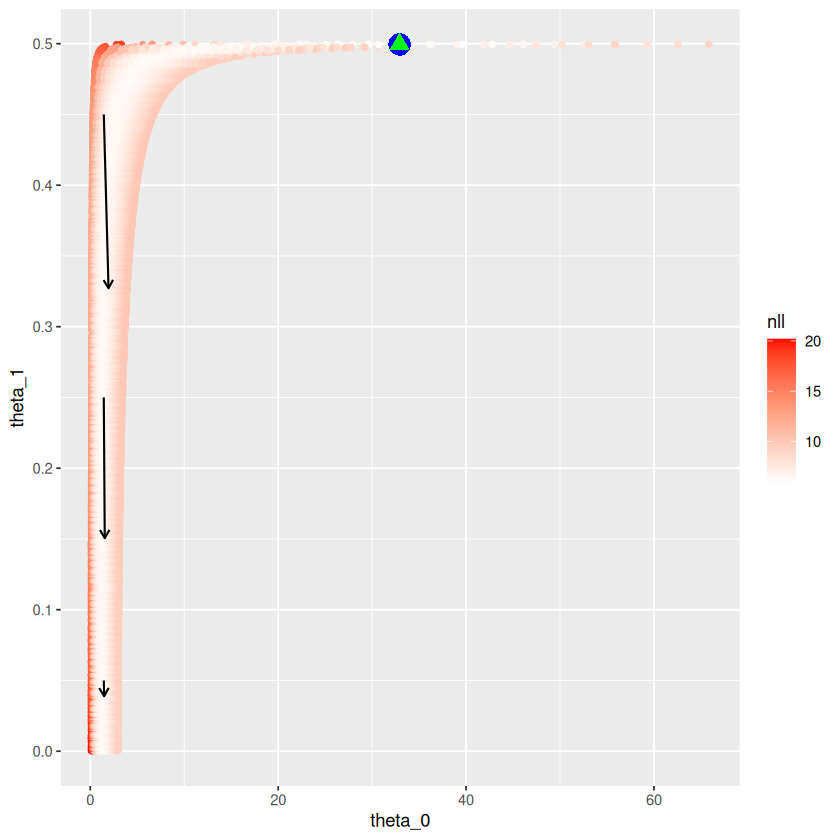

In [5]:
plot_methods(3,'SLSQP')